# Library Import

In [318]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image 
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import torch

In [319]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed before any operations
set_seed(42)

In [320]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [321]:
class SiameseNetworkDataset(Dataset):
    def __init__(self, imageFolderDataset, transform=None):
        self.imageFolderDataset = imageFolderDataset    
        self.transform = transform
        
    def __getitem__(self, index):
        img0_tuple = random.choice(self.imageFolderDataset.imgs)

        # We need approximately 50% of images to be in the same class
        should_get_same_class = random.randint(0, 1) 
        if should_get_same_class:
            while True:
                # Look until the same class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] == img1_tuple[1]:
                    break
        else:
            while True:
                # Look until a different class image is found
                img1_tuple = random.choice(self.imageFolderDataset.imgs) 
                if img0_tuple[1] != img1_tuple[1]:
                    break

        img0 = Image.open(img0_tuple[0])
        img1 = Image.open(img1_tuple[0])

        # Convert to RGB if image is in another format (e.g., RGBA)
        if img0.mode != 'RGB':
            img0 = img0.convert('RGB')
        if img1.mode != 'RGB':
            img1 = img1.convert('RGB')

        if self.transform is not None:
            img0 = self.transform(img0)
            img1 = self.transform(img1)
        
        # Return the images, similarity label (0 or 1), and the original class labels
        return img0, img1, torch.from_numpy(np.array([int(img1_tuple[1] != img0_tuple[1])], dtype=np.float32)), img0_tuple[1], img1_tuple[1]
    
    def __len__(self):
        return len(self.imageFolderDataset.imgs)

# Network

In [322]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
import torch.functional as F
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        
        # Using ResNet18 as the backbone with 3-channel input
        self.cnn1 = resnet18(pretrained=True)  # Using pretrained weights
        
        # Remove the original fully connected layer of ResNet18
        self.cnn1.fc = nn.Identity()
        
        # Setting up your custom Fully Connected Layers
        # ResNet18 outputs 512 features
        self.fc1 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.ReLU(inplace=True),
            nn.Linear(1024, 256),
        )
        
    def forward_once(self, x):
        # Forward pass through ResNet18
        output = self.cnn1(x)
        # Flatten the output
        output = output.view(output.size()[0], -1)
        # Forward pass through custom FC layers
        output = self.fc1(output)
        return output
    
    def forward(self, input1, input2):
        # Forward pass for both inputs
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        #output1 = F.normalize(output1, p=2, dim=1)
        #output2 = F.normalize(output2, p=2, dim=1)
        return output1, output2

In [323]:
# Initialize model and load weights
net = SiameseNetwork().to(DEVICE)
net.load_state_dict(torch.load("best_model_overall.pt", map_location=DEVICE))

/opt/anaconda3/envs/RAML/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/RAML/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

In [324]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)             # CPU seed
    torch.cuda.manual_seed(seed)        # GPU seed for current device
    torch.cuda.manual_seed_all(seed)    # GPU seed for all devices
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# If you want reproducible DataLoader shuffling, create a torch.Generator with fixed seed:
g = torch.Generator()
g.manual_seed(42)

# Your transformations and dataset
transformation_test = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

root = "data/faces/test/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                     transform=transformation_test)

test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=0, generator=g)


✅ Average Intra-Class Distance: 0.3088
✅ Average Inter-Class Distance: 0.9828


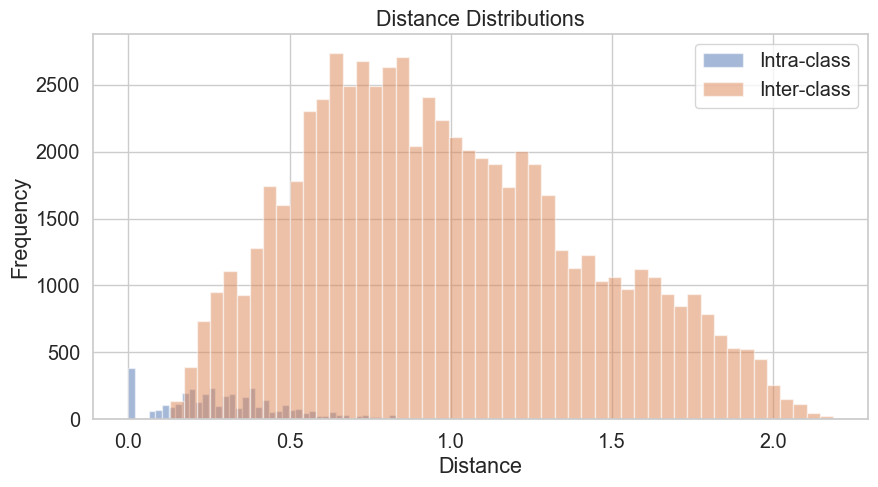

In [325]:
from collections import defaultdict
from itertools import combinations
import torch.nn.functional as F

# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in test_dataloader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

# Group embeddings by class
class_to_embeddings = defaultdict(list)
for emb, label in zip(all_embeddings, all_labels):
    class_to_embeddings[label.item()].append(emb)

for key in class_to_embeddings:
    class_to_embeddings[key] = torch.stack(class_to_embeddings[key])

# Compute intra-class distances
intra_dists = []
for emb_list in class_to_embeddings.values():
    for i, j in combinations(range(len(emb_list)), 2):
        dist = F.pairwise_distance(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        #dist = F.cosine_similarity(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        intra_dists.append(dist.item())

# Compute inter-class distances
inter_dists = []
label_keys = list(class_to_embeddings.keys())
for i in range(len(label_keys)):
    for j in range(i+1, len(label_keys)):
        emb_i = class_to_embeddings[label_keys[i]]
        emb_j = class_to_embeddings[label_keys[j]]
        for e1 in emb_i:
            for e2 in emb_j:
                dist = F.pairwise_distance(e1.unsqueeze(0), e2.unsqueeze(0))
                inter_dists.append(dist.item())

# Compute statistics
avg_intra = sum(intra_dists) / len(intra_dists)
avg_inter = sum(inter_dists) / len(inter_dists)

print(f"✅ Average Intra-Class Distance: {avg_intra:.4f}")
print(f"✅ Average Inter-Class Distance: {avg_inter:.4f}")

# Optional: Visualize distributions
plt.figure(figsize=(10, 5))
plt.hist(intra_dists, bins=50, alpha=0.5, label='Intra-class')
plt.hist(inter_dists, bins=50, alpha=0.5, label='Inter-class')
plt.title("Distance Distributions")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


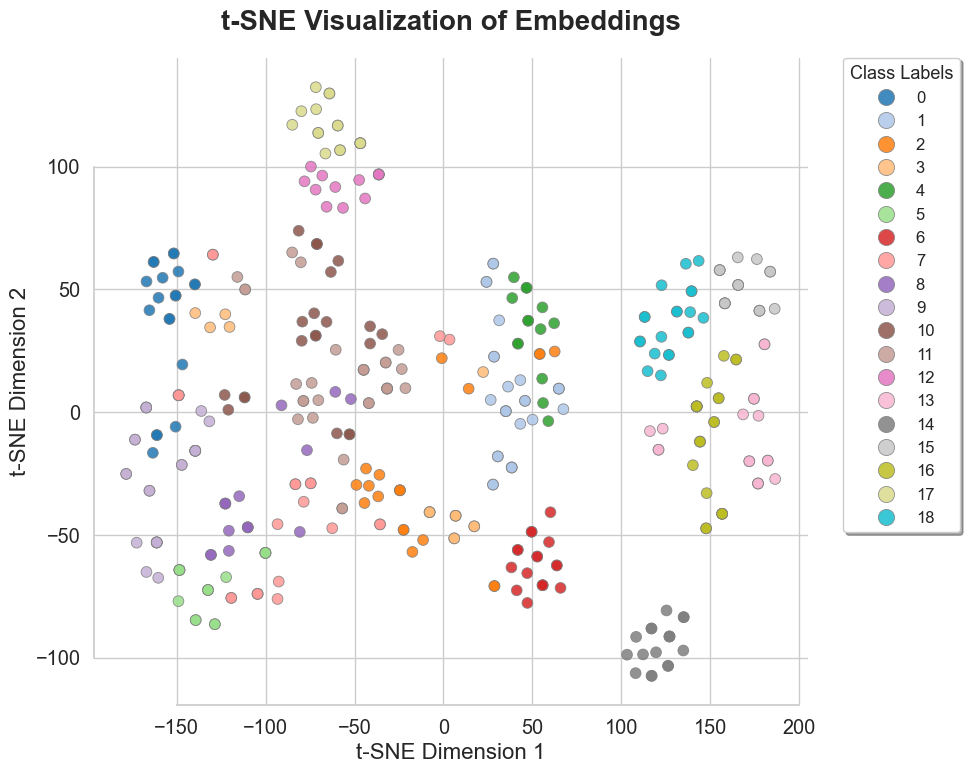

In [326]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

# Convert tensors to NumPy arrays
X = all_embeddings.cpu().numpy()
y = all_labels.cpu().numpy()

# Run t-SNE
tsne = TSNE(n_components=2, max_iter=1000, random_state=42, metric="euclidean")
X_tsne = tsne.fit_transform(X)

# Prepare the figure
plt.figure(figsize=(10, 8))
sns.set(style="whitegrid", font_scale=1.3)

# Generate a distinct color palette based on number of classes
num_classes = len(np.unique(y))
palette = sns.color_palette("tab20", num_classes) if num_classes <= 20 else sns.color_palette("husl", num_classes)

# Scatter plot with clean styling
scatter = sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=y,
    palette=palette,
    legend='full',
    s=60,             # bigger markers for visibility
    edgecolor='gray',  # subtle border around points for clarity
    alpha=0.85        # slight transparency for overlap clarity
)

# Title and labels
plt.title("t-SNE Visualization of Embeddings", fontsize=20, weight='bold', pad=20)
plt.xlabel("t-SNE Dimension 1", fontsize=16)
plt.ylabel("t-SNE Dimension 2", fontsize=16)

# Legend outside plot on the right, with larger markers
plt.legend(
    title="Class Labels",
    title_fontsize='13',
    fontsize='12',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    markerscale=1.5,
    frameon=True,
    shadow=True
)

# Remove top and right spines for a cleaner look
sns.despine(trim=True)

# Tight layout to use space well
plt.tight_layout()

plt.show()


In [327]:
def plot_evaluation_metrics(metrics_dict):
    """Plot evaluation metrics and confusion matrix in separate subplots."""
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot scalar metrics
    scalar_metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'avg_distance']
    scalar_values = [metrics_dict[k] for k in scalar_metrics]
    
    axs[0].bar(scalar_metrics, scalar_values, color='skyblue')
    axs[0].set_title("Evaluation Metrics")
    axs[0].set_ylim([0, 1])
    axs[0].tick_params(axis='x', rotation=45)
    for i, v in enumerate(scalar_values):
        axs[0].text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)

    # Plot confusion matrix
    cm = metrics_dict['confusion_matrix']
    cm_matrix = np.array([
        [cm['TP'], cm['FP']],
        [cm['FN'], cm['TN']]
    ])
    
    im = axs[1].imshow(cm_matrix, cmap='Blues')
    axs[1].set_title("Confusion Matrix")
    axs[1].set_xticks([0, 1])
    axs[1].set_yticks([0, 1])
    axs[1].set_xticklabels(['Predicted Similar', 'Predicted Dissimilar'])
    axs[1].set_yticklabels(['Actual Similar', 'Actual Dissimilar'])
    
    # Annotate confusion matrix
    for i in range(2):
        for j in range(2):
            axs[1].text(j, i, str(cm_matrix[i, j]), ha='center', va='center', color='black', fontsize=12)

    plt.tight_layout()
    plt.show()



Evaluation Metrics:
Accuracy: 0.8684
Precision: 0.8387
Recall: 0.8864
F1 Score: 0.8619
Avg Distance: 0.6163


/var/folders/kb/kmrwh0z16f1bq6q4bmbcnxvc0000gn/T/ipykernel_16134/3144192682.py:142: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kb/kmrwh0z16f1bq6q4bmbcnxvc0000gn/T/ipykernel_16134/3144192682.py:142: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/RAML/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/RAML/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


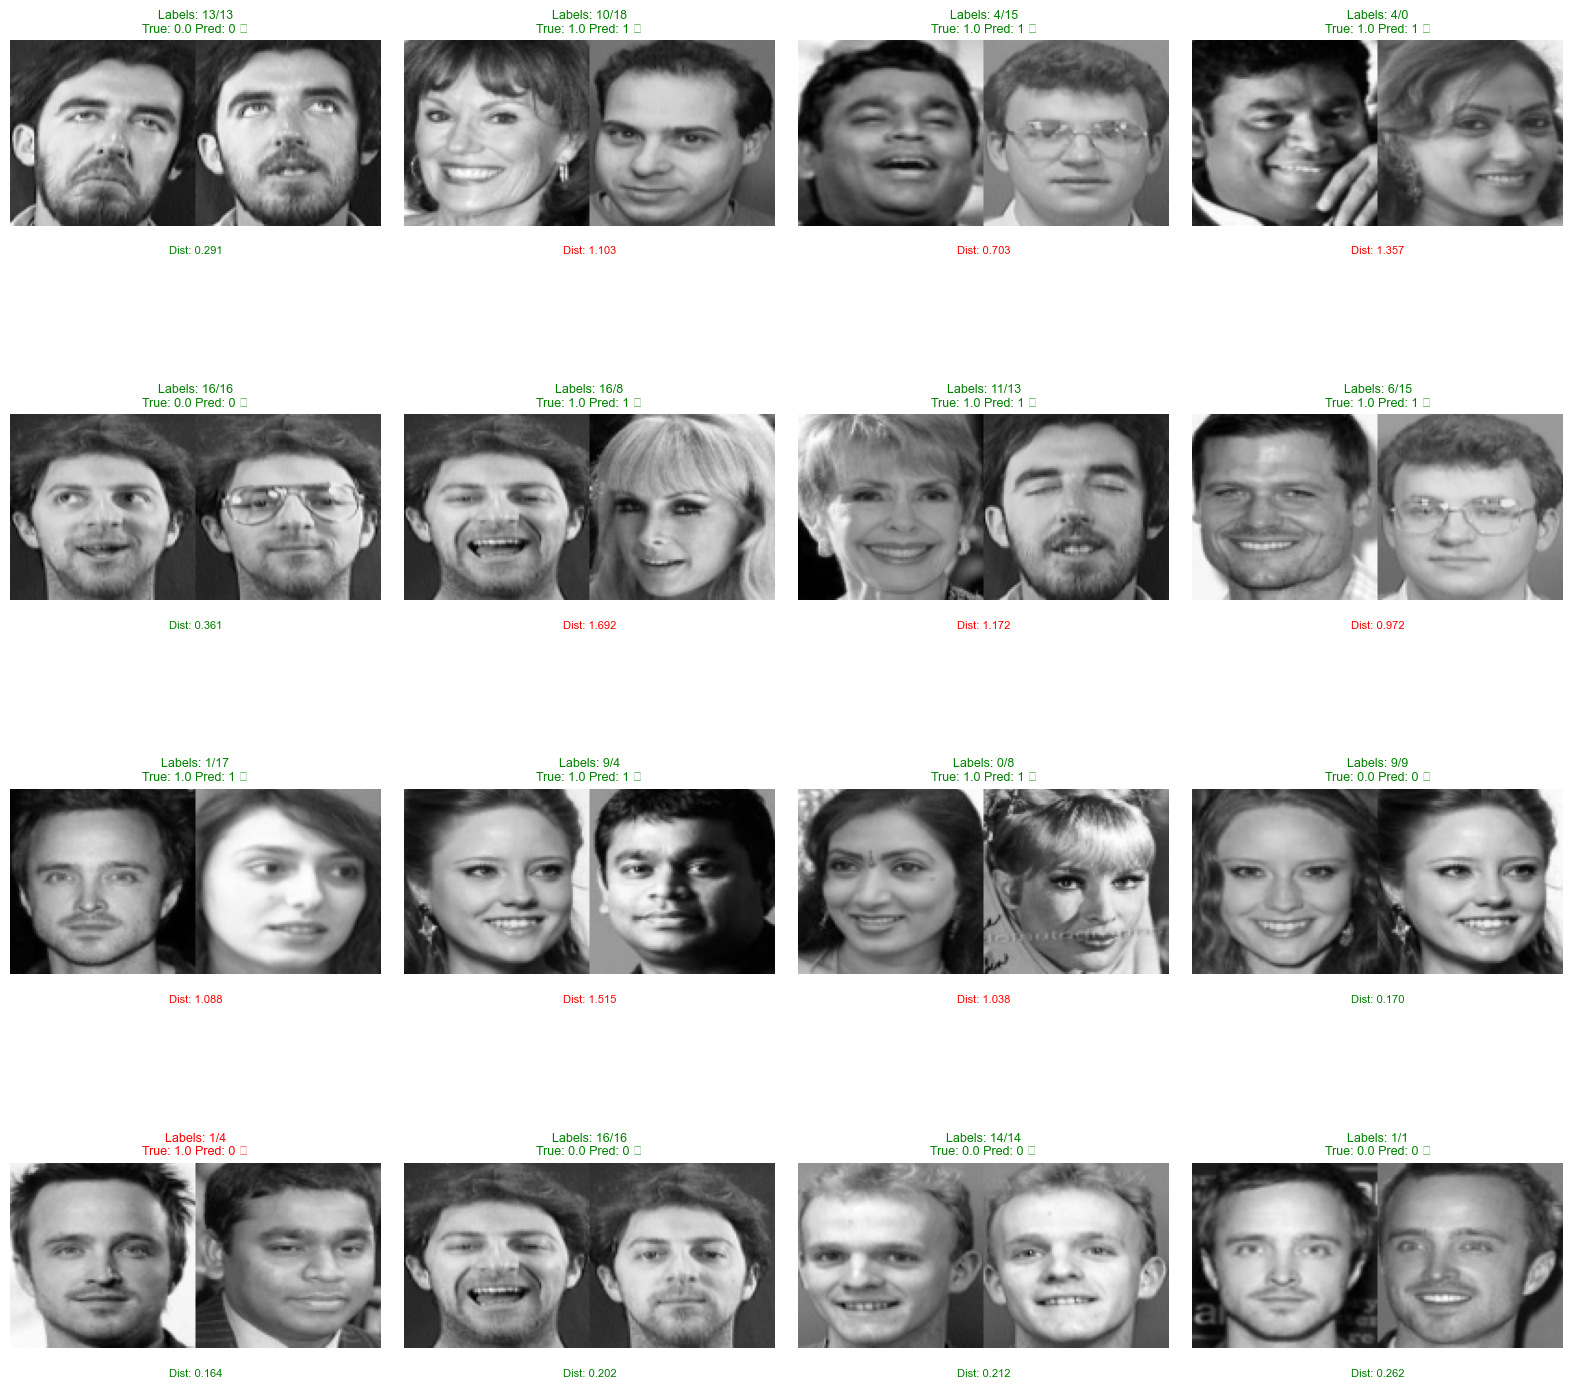

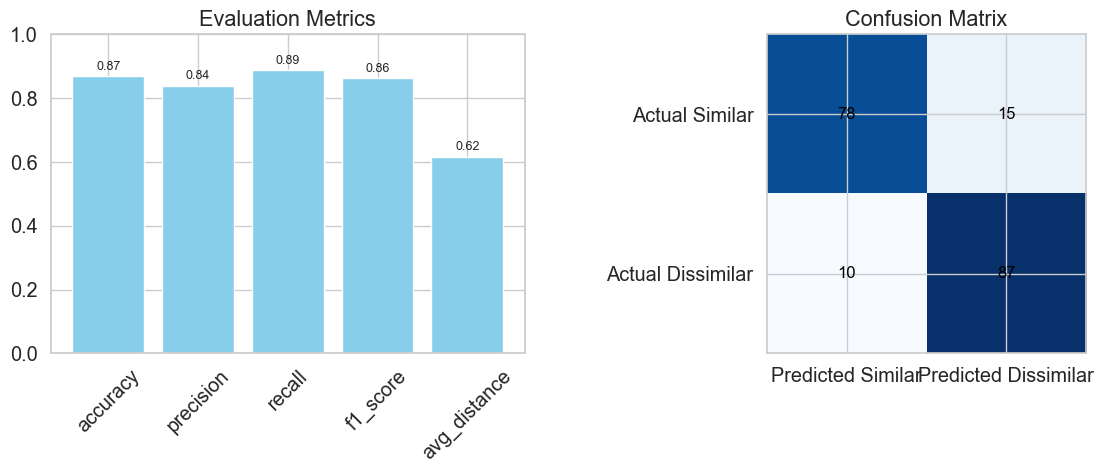

In [333]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
g.manual_seed(42)

def process_label(lbl):
    """Helper function to extract label value from various formats"""
    if isinstance(lbl, torch.Tensor):
        return lbl.item() if lbl.numel() == 1 else lbl[0].item()
    elif isinstance(lbl, (list, np.ndarray)):
        return lbl[0] if len(lbl) > 0 else lbl
    return lbl

def get_embeddings(model, img1, img2):
    """Get embeddings from the model for both images"""
    with torch.no_grad():
        model.eval()
        emb1, emb2 = model(img1, img2)
    return emb1, emb2

def evaluate_siamese_model(model, dataloader, distance_threshold=0.5):
    """Calculate comprehensive metrics using only Euclidean distance"""
    model.eval()
    
    # Initialize counters
    total_samples = 0
    true_positives = 0
    false_positives = 0
    true_negatives = 0
    false_negatives = 0
    distances = []
    
    with torch.no_grad():
        for img1, img2, label, _, _ in dataloader:
            img1, img2, label = img1.to(DEVICE), img2.to(DEVICE), label.to(DEVICE)
            
            # Get embeddings and distances
            emb1, emb2 = model(img1, img2)
            euclidean_dist = F.pairwise_distance(emb1, emb2)
            
            # Convert to numpy
            euclidean_dist = euclidean_dist.cpu().numpy()
            #euclidean_dist = F.cosine_similarity(emb1, emb2).cpu().numpy()
            labels = label.cpu().numpy()
            
            # Update metrics
            for i in range(len(labels)):
                total_samples += 1
                pred = 0 if euclidean_dist[i] <= distance_threshold else 1
                true_label = labels[i]
                
                if pred == 0 and true_label == 0:
                    true_positives += 1
                elif pred == 0 and true_label == 1:
                    false_positives += 1
                elif pred == 1 and true_label == 1:
                    true_negatives += 1
                else:
                    false_negatives += 1
                
                distances.append(euclidean_dist[i])
    
    # Calculate metrics
    accuracy = (true_positives + true_negatives) / total_samples
    precision = true_positives / (true_positives + false_positives + 1e-10)
    recall = true_positives / (true_positives + false_negatives + 1e-10)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'avg_distance': np.mean(distances),
        'confusion_matrix': {
            'TP': true_positives,
            'FP': false_positives,
            'TN': true_negatives,
            'FN': false_negatives
        }
    }

def plot_samples_with_metrics(test_loader, model, n_samples=8, n_cols=4, distance_threshold=0.5):
    """Visualize sample pairs with distance metrics"""
    pairs_imgs = []
    
    for _ in range(n_samples):
        img1, img2, label, label1, label2 = next(iter(test_loader))
        lbl1 = process_label(label1)
        lbl2 = process_label(label2)
        true_label = process_label(label)

        # Get embeddings and distance
        emb1, emb2 = get_embeddings(model, img1.to(DEVICE), img2.to(DEVICE))
        euclid = F.pairwise_distance(emb1, emb2).mean().item()
        #euclid = F.cosine_similarity(emb1, emb2).mean().item()
        pred = 0 if euclid <= distance_threshold else 1
        
        # Prepare image
        img1_gray = img1[0].cpu().mean(dim=0, keepdim=True)
        img2_gray = img2[0].cpu().mean(dim=0, keepdim=True)
        concat_img = torch.cat((img1_gray, img2_gray), dim=2)
        
        pairs_imgs.append((
            concat_img.squeeze(0), 
            lbl1, lbl2, 
            euclid,
            true_label, pred
        ))

    # Create figure
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_samples > 1:
        axs = axs.flatten()
    else:
        axs = [axs]

    for i, ax in enumerate(axs):
        if i < n_samples:
            img, lbl1, lbl2, euclid, true_label, pred = pairs_imgs[i]
            
            # Display image
            ax.imshow(img.numpy(), cmap='gray')
            ax.axis('off')
            
            # Prediction correctness
            correct = "✓" if pred == true_label else "✗"
            title_color = "green" if correct == "✓" else "red"
            
            ax.set_title(f"Labels: {lbl1}/{lbl2}\nTrue: {true_label} Pred: {pred} {correct}", 
                        fontsize=9, color=title_color)

            # Distance info
            dist_color = "green" if euclid <= distance_threshold else "red"
            ax.text(0.5, -0.15, f"Dist: {euclid:.3f}", 
                   transform=ax.transAxes, ha='center', fontsize=8, color=dist_color)
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
if __name__ == "__main__":
    # Calculate metrics
    metrics = evaluate_siamese_model(net, test_dataloader)
    print("\nEvaluation Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1_score']:.4f}")
    print(f"Avg Distance: {metrics['avg_distance']:.4f}")
    
    # Visualize samples
    plot_samples_with_metrics(test_dataloader, net, n_samples= 16, distance_threshold=0.5)
    plot_evaluation_metrics(metrics)